# EX 6C – Baseball Databank / Power BI

Same Power BI transformation, KPI and visual workflow as the friend's EX 6C, adapted to Baseball batting statistics.

In [1]:
from pathlib import Path

def find_data(filename):
    candidates = [
        Path(filename),
        Path("data") / filename,
        Path("../data") / filename,
        Path("../../data") / filename,
        Path("/content") / filename,
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"{filename} not found. Upload the Baseball Databank CSV or keep it in the repository data folder.")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(find_data("Batting.csv"))
print("Dataset loaded successfully")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.head()

Dataset loaded successfully
Rows: 101332
Columns: 22


,playerID,yearID,stint,teamID,lgID,G,AB,R,H,2B,3B,HR,RBI,SB,CS,BB,SO,IBB,HBP,SH,SF,GIDP
0,abercda01,1871,1,TRO,NaN,1,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1,addybo01,1871,1,RC1,NaN,25,118.0,30.0,32.0,6.0,0.0,0.0,13.0,8.0,1.0,4.0,0.0,NaN,NaN,NaN,NaN,NaN
2,allisar01,1871,1,CL1,NaN,29,137.0,28.0,40.0,4.0,5.0,0.0,19.0,3.0,1.0,2.0,5.0,NaN,NaN,NaN,NaN,NaN
3,allisdo01,1871,1,WS3,NaN,27,133.0,28.0,44.0,10.0,2.0,2.0,27.0,1.0,1.0,0.0,2.0,NaN,NaN,NaN,NaN,NaN
4,ansonca01,1871,1,RC1,NaN,25,120.0,29.0,39.0,11.0,3.0,0.0,16.0,6.0,2.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN


In [2]:
print("Duplicate rows:", df.duplicated().sum())
print("\nMissing values:")
display(df.isna().sum().to_frame("Missing Values"))

Duplicate rows: 0

Missing values:


,Missing Values
playerID,0
yearID,0
stint,0
teamID,0
lgID,737
G,0
AB,5149
R,5149
H,5149
2B,5149


In [3]:
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

for col in df.select_dtypes(include=["object"]).columns:
    df[col] = df[col].fillna("Unknown")

df["total_runs"] = df["R"]
df["is_home_run"] = (df["HR"] > 0).astype(int)

df["yearID"] = df["yearID"].astype(int)

print("Transformed columns added: total_runs, is_home_run")
print("Year range:", df["yearID"].min(), "to", df["yearID"].max())

Transformed columns added: total_runs, is_home_run
Year range: 1871 to 2015


In [4]:
metrics = pd.DataFrame({
    "Metric": ["Player-Seasons", "Players", "Total Runs", "Total Home Runs", "Seasons"],
    "Value": [
        len(df),
        df["playerID"].nunique(),
        int(df["total_runs"].sum()),
        int(df["HR"].sum()),
        df["yearID"].nunique()
    ]
})
metrics

,Metric,Value
0,Player-Seasons,101332
1,Players,18659
2,Total Runs,1912795
3,Total Home Runs,283673
4,Seasons,145


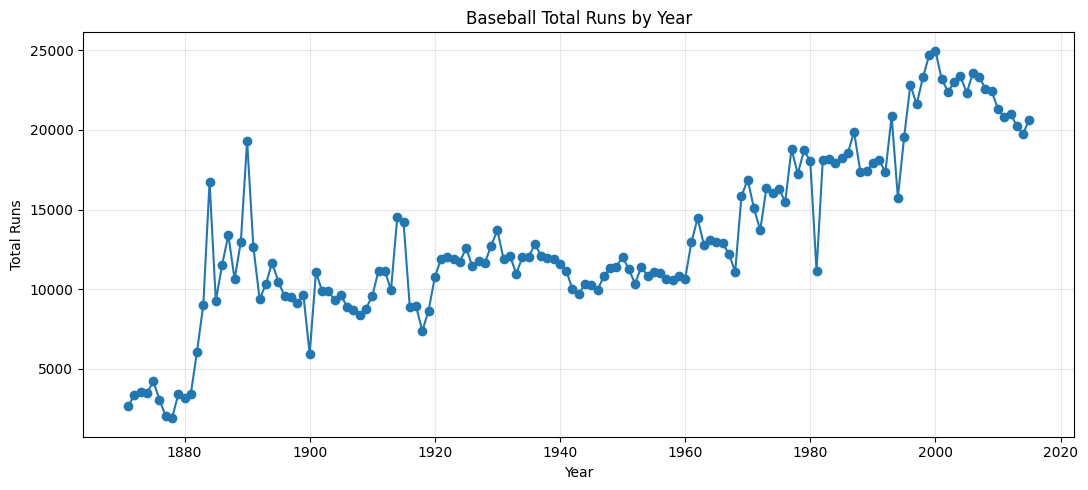

In [5]:
season_runs = df.groupby("yearID")["total_runs"].sum()

plt.figure(figsize=(11,5))
season_runs.plot(kind="line", marker="o")
plt.title("Baseball Total Runs by Year")
plt.xlabel("Year")
plt.ylabel("Total Runs")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Experiment_6C_Baseball_Year_Line.png", dpi=150, bbox_inches="tight")
plt.show()

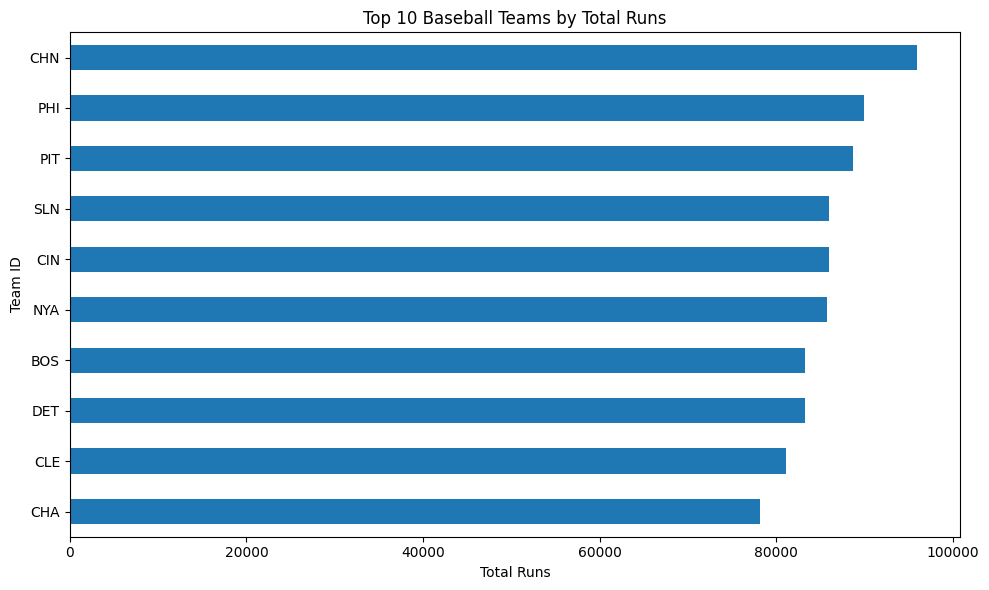

In [6]:
team_runs = df.groupby("teamID")["total_runs"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
team_runs.sort_values().plot(kind="barh")
plt.title("Top 10 Baseball Teams by Total Runs")
plt.xlabel("Total Runs")
plt.ylabel("Team ID")
plt.tight_layout()
plt.savefig("Experiment_6C_Baseball_Team_Bar.png", dpi=150, bbox_inches="tight")
plt.show()

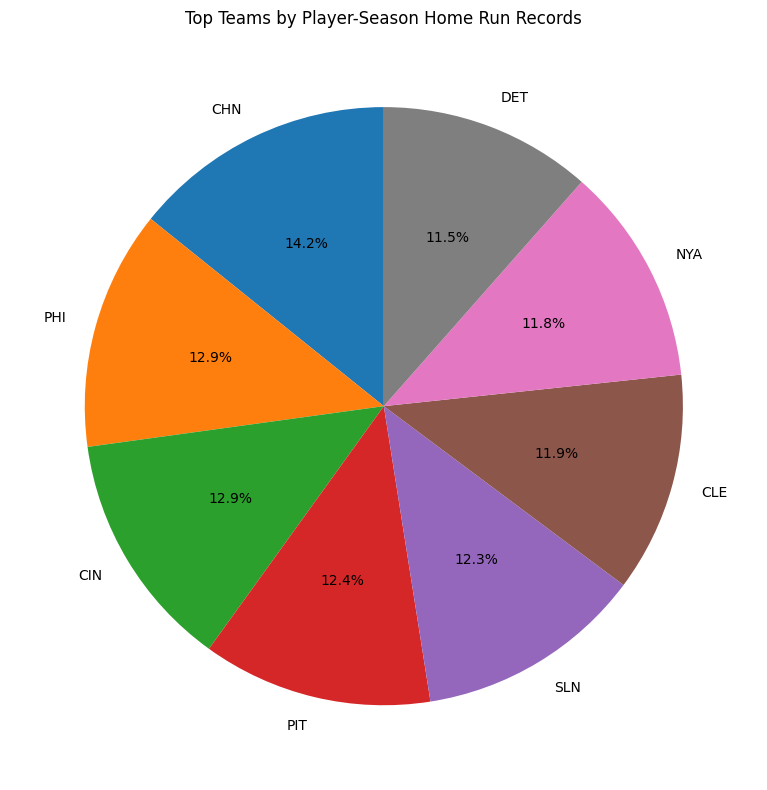

In [7]:
home_run_counts = df.loc[df["is_home_run"] == 1, "teamID"].value_counts().head(8)

plt.figure(figsize=(8,8))
plt.pie(home_run_counts.values, labels=home_run_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Top Teams by Player-Season Home Run Records")
plt.tight_layout()
plt.savefig("Experiment_6C_Baseball_HomeRun_Pie.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
print("DAX examples for Power BI:")
print("Total Runs = SUM(Batting[total_runs])")
print("Total Players = DISTINCTCOUNT(Batting[playerID])")
print("Total Player-Seasons = COUNTROWS(Batting)")
print("Total Home Runs = SUM(Batting[HR])")

DAX examples for Power BI:
Total Runs = SUM(Batting[total_runs])
Total Players = DISTINCTCOUNT(Batting[playerID])
Total Player-Seasons = COUNTROWS(Batting)
Total Home Runs = SUM(Batting[HR])
